# Task 1 - Data Preprocessing and Exploratory Data Analysis
## Portfolio: TSLA, BND, SPY | Period: 2015-2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
print("Libraries loaded")

Libraries loaded


## 1. Load and Inspect Data

In [2]:
df = pd.read_csv("../data/processed/prices.csv", index_col=0, parse_dates=True)
print("Shape:", df.shape)
print("\nDate range:", df.index[0], "to", df.index[-1])
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n")
df.describe().round(2)

Shape: (2888, 3)

Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

Missing values:
 TSLA    0
BND     0
SPY     0
dtype: int64

Basic stats:



,TSLA,BND,SPY
count,2888.00,2888.00,2888.00
mean,148.77,66.50,351.51
std,138.90,4.71,155.44
min,9.58,58.73,154.16
25%,18.39,62.48,223.55
50%,133.44,65.73,312.82
75%,251.93,70.69,432.81
max,489.88,74.83,757.62


## 2. Closing Price Trends

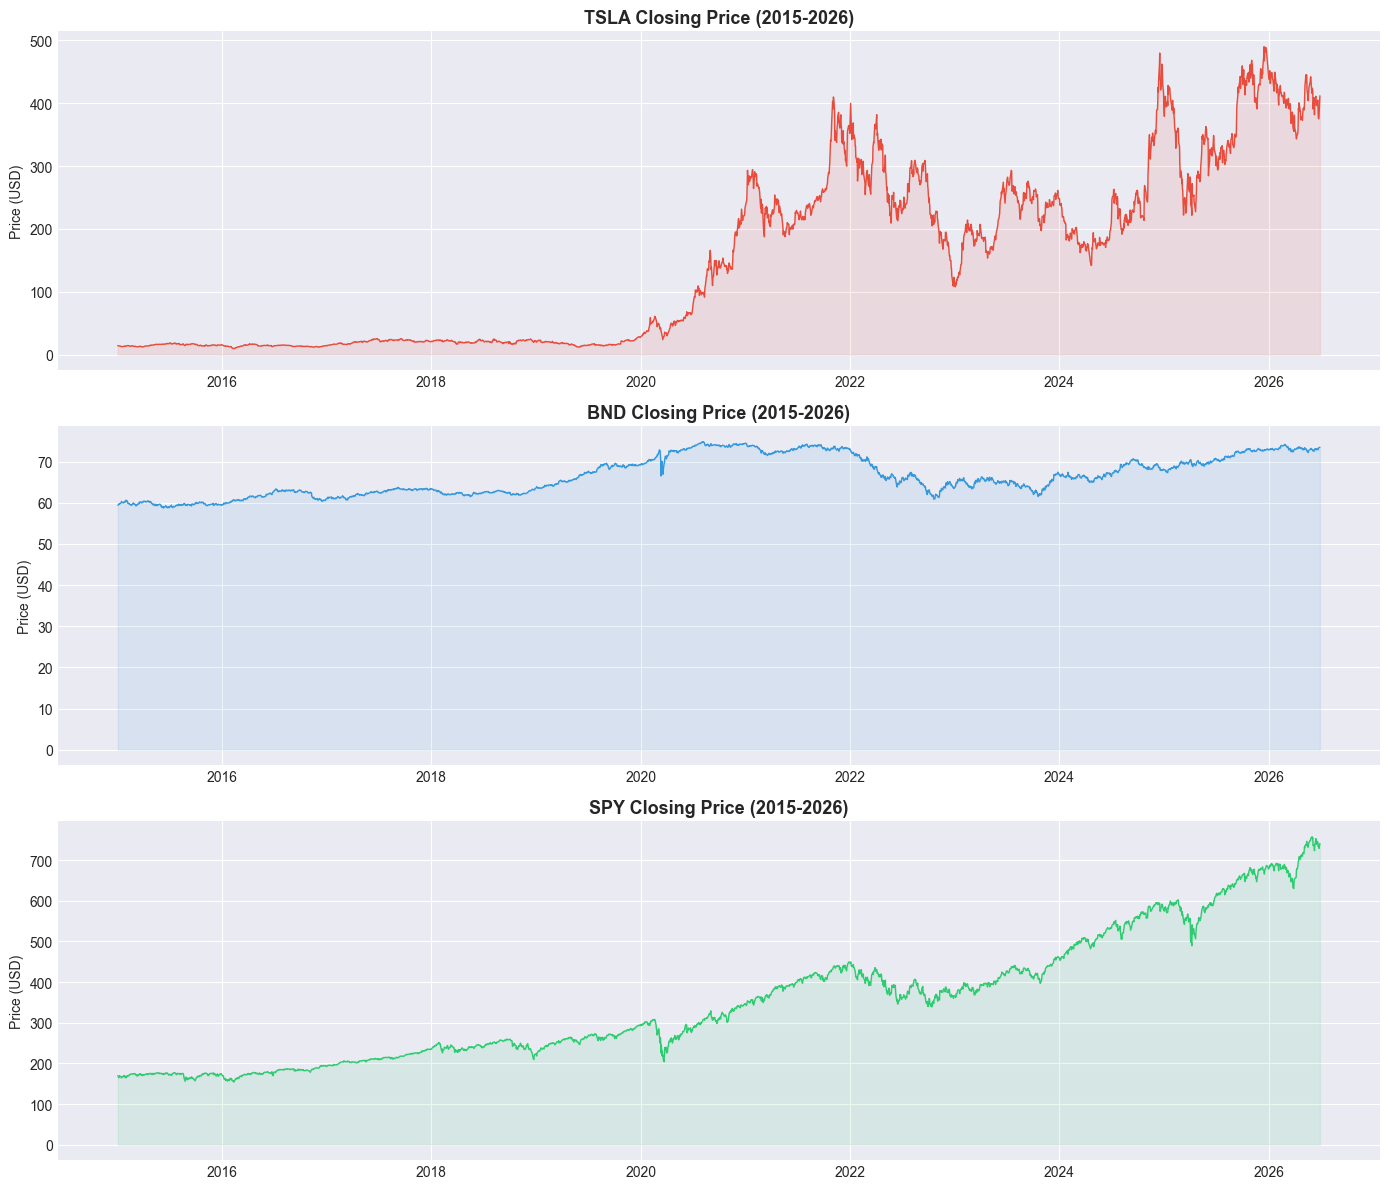

Figure 1: Closing prices saved


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
for i, (col, color) in enumerate(zip(df.columns, colors)):
    axes[i].plot(df.index, df[col], color=color, linewidth=1)
    axes[i].set_title(f"{col} Closing Price (2015-2026)", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Price (USD)")
    axes[i].fill_between(df.index, df[col], alpha=0.1, color=color)
plt.tight_layout()
plt.savefig("../data/processed/closing_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1: Closing prices saved")

## 3. Daily Returns and Volatility

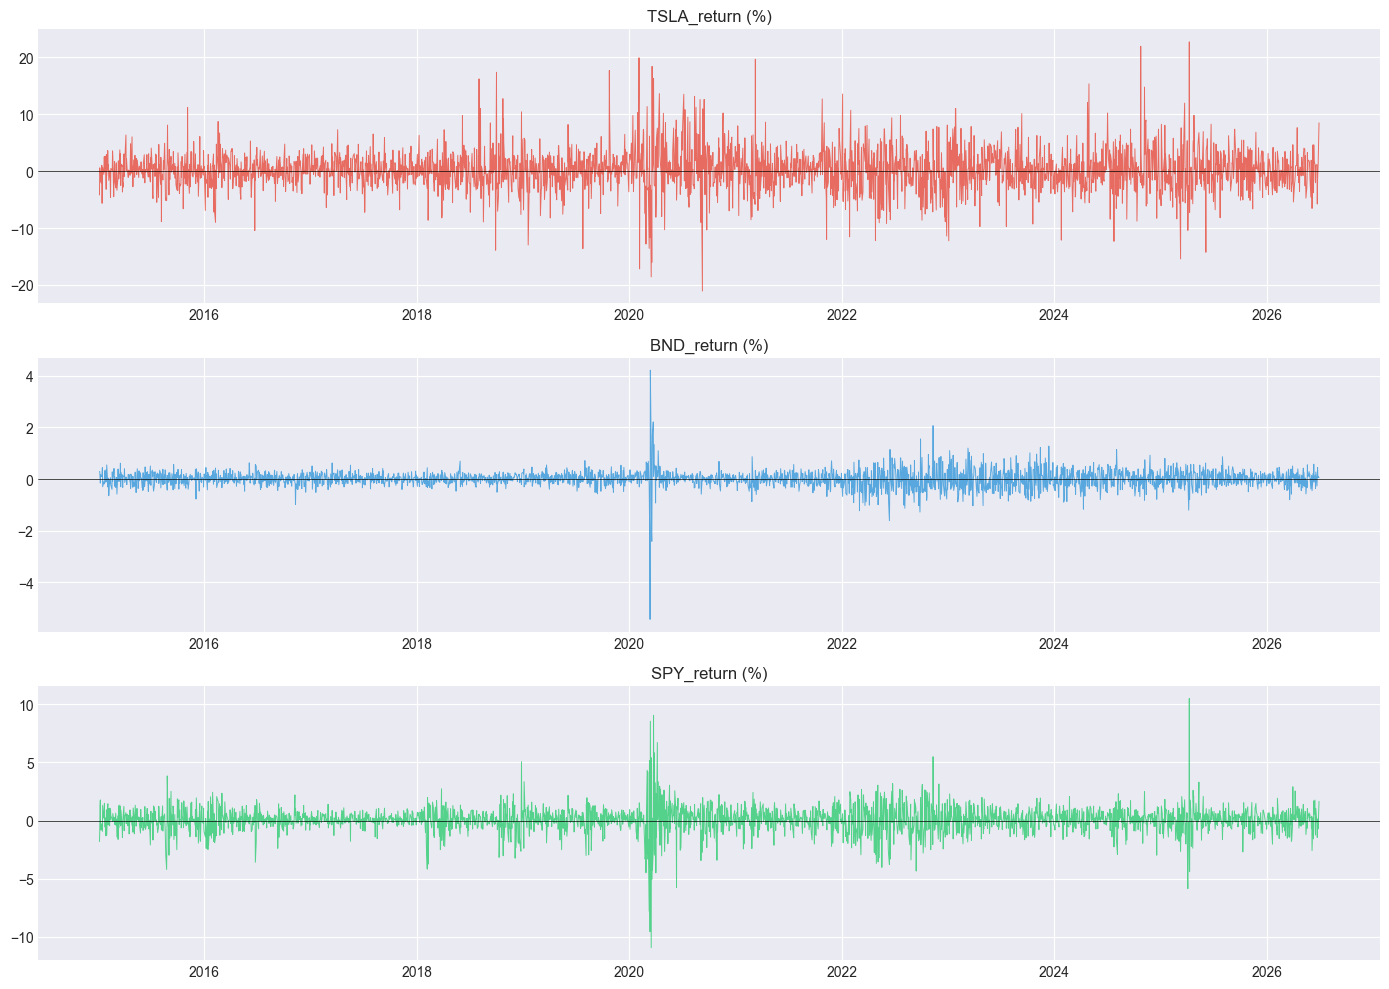

Figure 2: Daily returns saved

Return statistics:


,TSLA_return,BND_return,SPY_return
count,2887.0000,2887.0000,2887.0000
mean,0.0018,0.0001,0.0006
std,0.0360,0.0033,0.0111
min,-0.2106,-0.0544,-0.1094
25%,-0.0166,-0.0015,-0.0037
50%,0.0012,0.0001,0.0007
75%,0.0195,0.0018,0.0059
max,0.2269,0.0422,0.1050


In [4]:
returns = df.pct_change().dropna()
returns.columns = [c + "_return" for c in df.columns]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
for i, (col, color) in enumerate(zip(returns.columns, colors)):
    axes[i].plot(returns.index, returns[col]*100, color=color, linewidth=0.7, alpha=0.8)
    axes[i].set_title(f"{col} (%)", fontsize=12)
    axes[i].axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("../data/processed/daily_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2: Daily returns saved")
print("\nReturn statistics:")
returns.describe().round(4)

## 4. Rolling Volatility (30-day)

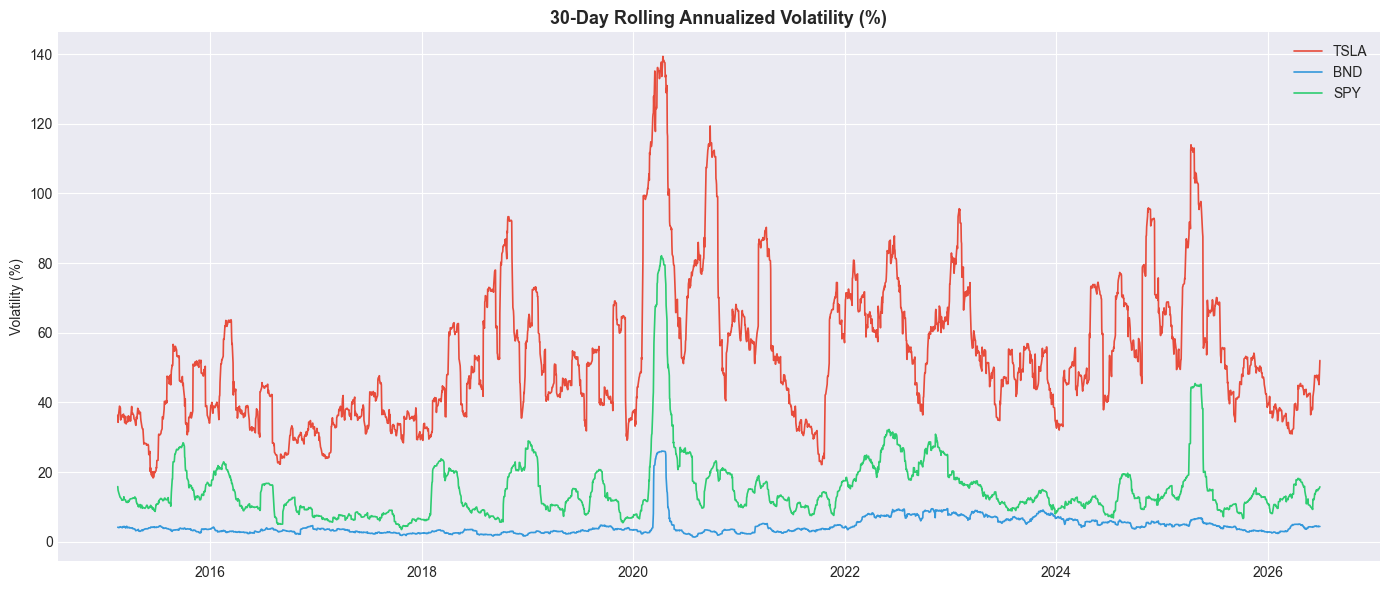

Figure 3: Rolling volatility saved


In [5]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(14, 6))
for col, color, label in zip(rolling_vol.columns, ["#e74c3c","#3498db","#2ecc71"], ["TSLA","BND","SPY"]):
    ax.plot(rolling_vol.index, rolling_vol[col]*100, label=label, color=color, linewidth=1.2)
ax.set_title("30-Day Rolling Annualized Volatility (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Volatility (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3: Rolling volatility saved")

## 5. Stationarity Test (Augmented Dickey-Fuller)

In [6]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary: {result[1] < 0.05}")
    return result[1] < 0.05

print("=== Closing Prices (Raw) ===")
for col in df.columns:
    adf_test(df[col], col)

print("\n=== Daily Returns ===")
for col in returns.columns:
    adf_test(returns[col], col)

=== Closing Prices (Raw) ===



TSLA:
  ADF Statistic: -1.0696
  p-value: 0.7270
  Stationary: False

BND:
  ADF Statistic: -1.0827
  p-value: 0.7219
  Stationary: False



SPY:
  ADF Statistic: 1.3089
  p-value: 0.9967
  Stationary: False

=== Daily Returns ===

TSLA_return:
  ADF Statistic: -53.9719
  p-value: 0.0000
  Stationary: True



BND_return:
  ADF Statistic: -15.2161
  p-value: 0.0000
  Stationary: True

SPY_return:
  ADF Statistic: -17.5722
  p-value: 0.0000
  Stationary: True


## 6. Risk Metrics: VaR and Sharpe Ratio

=== Value at Risk (95% confidence) ===
TSLA_return: -5.17%
BND_return: -0.48%
SPY_return: -1.66%

=== Sharpe Ratio (annualized, risk-free=2%) ===
TSLA_return: 0.76
BND_return: -0.00
SPY_return: 0.70

=== Correlation Matrix ===
             TSLA_return  BND_return  SPY_return
TSLA_return        1.000       0.059       0.494
BND_return         0.059       1.000       0.116
SPY_return         0.494       0.116       1.000


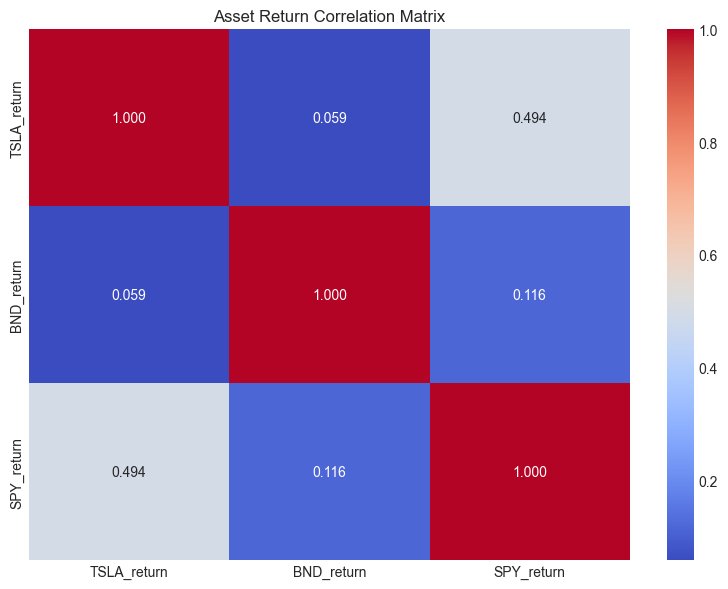

In [7]:
print("=== Value at Risk (95% confidence) ===")
for col in returns.columns:
    var_95 = np.percentile(returns[col], 5)
    print(f"{col}: {var_95*100:.2f}%")

print("\n=== Sharpe Ratio (annualized, risk-free=2%) ===")
rf = 0.02 / 252
for col in returns.columns:
    excess = returns[col] - rf
    sharpe = (excess.mean() / excess.std()) * np.sqrt(252)
    print(f"{col}: {sharpe:.2f}")

print("\n=== Correlation Matrix ===")
corr = returns.corr()
print(corr.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", ax=ax)
ax.set_title("Asset Return Correlation Matrix")
plt.tight_layout()
plt.savefig("../data/processed/correlation.png", dpi=150, bbox_inches="tight")
plt.show()